In [151]:
import pandas as pd
import numpy as np

In [152]:
train = pd.read_csv("ml-ai-hackathon-2026/train_games.csv")
test = pd.read_csv("ml-ai-hackathon-2026/test_features.csv")

genre = pd.read_csv("ml-ai-hackathon-2026/genre_summary.csv")
platform = pd.read_csv("ml-ai-hackathon-2026/platform_summary.csv")
publisher = pd.read_csv("ml-ai-hackathon-2026/publisher_summary.csv")
yearly = pd.read_csv("ml-ai-hackathon-2026/yearly_trends.csv")

## Train Preprocessing

In [153]:
train = train.merge(
    publisher,
    on=["publisher", "publisher_tier"],
    how="left"
)

In [154]:
train = train.merge(platform,
           on=["platform","platform_generation"],
           how = "left")

In [155]:
train = train.merge(
    genre,
    on=['genre', 'platform_type'],
    how='left'
)

In [156]:
train.shape

(40000, 54)

In [157]:
set(yearly.columns) - set(train.columns)

set()

In [158]:
rename_dict = {
    # Titles
    'titles_x': 'publisher_titles',
    'titles_y': 'platform_titles',
    'titles': 'genre_titles',

    # Revenue average
    'avg_estimated_revenue_million_usd_x': 'publisher_avg_revenue',
    'avg_estimated_revenue_million_usd_y': 'platform_avg_revenue',
    'avg_estimated_revenue_million_usd': 'genre_avg_revenue',

    # Metacritic scores
    'avg_metacritic_score_x': 'publisher_avg_metacritic_score',
    'avg_metacritic_score_y': 'platform_avg_metacritic_score',
    'avg_metacritic_score': 'genre_avg_metacritic_score',

    # User scores
    'avg_user_score_x': 'publisher_avg_user_score',
    'avg_user_score_y': 'platform_avg_user_score',
    'avg_user_score': 'genre_avg_user_score',

    # Launch prices
    'avg_launch_price_usd_x': 'publisher_avg_launch_price_usd',
    'avg_launch_price_usd_y': 'platform_avg_launch_price_usd',
    'avg_launch_price_usd': 'genre_avg_launch_price_usd',

    # Percentages
    'pct_sequel': 'publisher_pct_sequel',
    'pct_online_multiplayer_x': 'platform_pct_online_multiplayer',
    'pct_online_multiplayer_y': 'genre_pct_online_multiplayer',
    'pct_dlc_released': 'genre_pct_dlc_released',
    'pct_microtransactions': 'genre_pct_microtransactions'
}

train.rename(columns=rename_dict, inplace=True)

In [159]:
leak_cols = [
    'publisher_avg_revenue',
    'platform_avg_revenue',
    'genre_avg_revenue'
]

train.drop(columns=leak_cols, inplace=True)

In [160]:
train_backup = train.copy()

In [161]:
train.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer',
       'publisher_region', 'publisher_tier', 'esrb_rating', 'metacritic_score',
       'user_score', 'critic_review_count', 'user_review_count',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'publisher_is_developer', 'internal_build_id',
       'marketing_campaign_type', 'day_one_patch_size_mb', 'publisher_titles',
       'publisher_avg_metacritic_score', 'publisher_avg_user_score',
       'publisher_avg_launch_price_usd', 'publisher_pct_sequel',
       'platform_titles', 'platform_avg_metacritic_score',
       'platform_avg_user_score', 'platform_avg_launch_price_usd',
       'platfo

In [162]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   game_id                             40000 non-null  str    
 1   title                               40000 non-null  str    
 2   platform                            40000 non-null  str    
 3   platform_type                       40000 non-null  str    
 4   platform_maker                      40000 non-null  str    
 5   platform_generation                 40000 non-null  int64  
 6   genre                               40000 non-null  str    
 7   year                                40000 non-null  int64  
 8   publisher                           40000 non-null  str    
 9   developer                           40000 non-null  str    
 10  publisher_region                    40000 non-null  str    
 11  publisher_tier                      40000 non-null  

In [163]:
train.isnull().sum().sort_values(ascending= False).head(5)

marketing_campaign_type       9995
metacritic_score              6000
user_review_count             6000
critic_review_count           6000
genre_avg_metacritic_score       1
dtype: int64

In [164]:
num_cols = train.select_dtypes(include=['int64','float64']).columns
cat_cols = train.select_dtypes(include=['object']).columns

for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

/var/folders/2f/vs0p3bp12mvg2870k7c_rmr80000gn/T/ipykernel_13085/2726477208.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).columns


In [165]:
train.isnull().sum().sum()

np.int64(0)

In [166]:
for col in train.select_dtypes(include=['object']).columns:
    print(col, train[col].nunique())

game_id 40000
title 1389
platform 30
platform_type 7
platform_maker 8
genre 20
publisher 51
developer 51
publisher_region 15
publisher_tier 3
esrb_rating 6
internal_build_id 40000
marketing_campaign_type 3


/var/folders/2f/vs0p3bp12mvg2870k7c_rmr80000gn/T/ipykernel_13085/3695308146.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(include=['object']).columns:


In [167]:
drop_cols = ['game_id','title','internal_build_id']
train.drop(columns=drop_cols,inplace=True)

In [168]:
for col in train.select_dtypes(include=['object']).columns:
    print(col, train[col].nunique())

platform 30
platform_type 7
platform_maker 8
genre 20
publisher 51
developer 51
publisher_region 15
publisher_tier 3
esrb_rating 6
marketing_campaign_type 3


/var/folders/2f/vs0p3bp12mvg2870k7c_rmr80000gn/T/ipykernel_13085/3695308146.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(include=['object']).columns:


## EDA

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

In [170]:
train.columns

Index(['platform', 'platform_type', 'platform_maker', 'platform_generation',
       'genre', 'year', 'publisher', 'developer', 'publisher_region',
       'publisher_tier', 'esrb_rating', 'metacritic_score', 'user_score',
       'critic_review_count', 'user_review_count',
       'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'publisher_is_developer', 'marketing_campaign_type',
       'day_one_patch_size_mb', 'publisher_titles',
       'publisher_avg_metacritic_score', 'publisher_avg_user_score',
       'publisher_avg_launch_price_usd', 'publisher_pct_sequel',
       'platform_titles', 'platform_avg_metacritic_score',
       'platform_avg_user_score', 'platform_avg_launch_price_usd',
       'platform_pct_online_multiplayer', 'genre_titles

In [171]:
yearly_revenue = (
    train.groupby('year')['estimated_revenue_million_usd']
         .mean()
         .reset_index()
)

In [172]:
yearly_revenue.head()

,year,estimated_revenue_million_usd
0,1985,732.213849
1,1986,789.232676
2,1987,760.982713
3,1988,754.566536
4,1989,690.201574


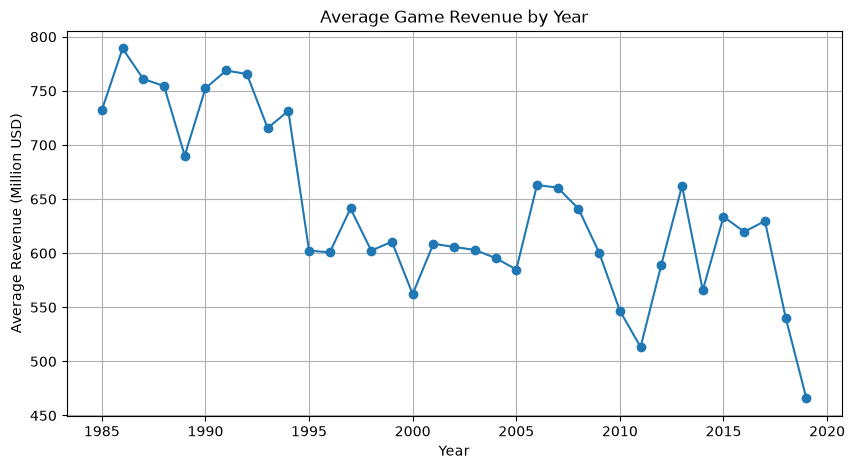

In [173]:
plt.figure(figsize=(10,5))
plt.plot(yearly_revenue['year'],
         yearly_revenue['estimated_revenue_million_usd'],
         marker='o')

plt.xlabel("Year")
plt.ylabel("Average Revenue (Million USD)")
plt.title("Average Game Revenue by Year")
plt.grid(True)
plt.show()

## Feature Engineering for Train

In [174]:
cols_to_drop = [
    "game_pass_available",
    "publisher_tier",
    "platform_type",
    "vr_support",
    "goty_won",
    "loot_boxes",
    "online_multiplayer",
    "microtransactions"
]

train.drop(columns=cols_to_drop, inplace=True)

In [175]:
# Interaction Features

# Metacritic × User Score
train["score_interaction"] = (
    train["metacritic_score"] * train["user_score"]
)

# Total Reviews
train["total_reviews"] = (
    train["critic_review_count"] +
    train["user_review_count"]
)

# Critic/User Review Ratio
train["review_ratio"] = (
    train["critic_review_count"] /
    (train["user_review_count"] + 1)
)

# Value for Money (Hours per Dollar)
train["value_for_money"] = (
    train["how_long_to_beat_main_hrs"] /
    (train["launch_price_usd"] + 1)
)

# Completion Ratio
train["completion_ratio"] = (
    train["how_long_to_beat_completionist_hrs"] /
    (train["how_long_to_beat_main_hrs"] + 1)
)

# Difference from Averages

# Price compared to genre average
train["price_vs_genre_avg"] = (
    train["launch_price_usd"] -
    train["genre_avg_launch_price_usd"]
)

# Price compared to platform average
train["price_vs_platform_avg"] = (
    train["launch_price_usd"] -
    train["platform_avg_launch_price_usd"]
)

# Price compared to publisher average
train["price_vs_publisher_avg"] = (
    train["launch_price_usd"] -
    train["publisher_avg_launch_price_usd"]
)

# User score compared to genre average
train["user_score_vs_genre_avg"] = (
    train["user_score"] -
    train["genre_avg_user_score"]
)

# Metacritic score compared to genre average
train["metacritic_vs_genre_avg"] = (
    train["metacritic_score"] -
    train["genre_avg_metacritic_score"]
)

# Boolean Features

# Highly rated and highly reviewed
train["high_review_high_score"] = (
    (train["metacritic_score"] > 80) &
    (train["critic_review_count"] > 100)
).astype(int)

# Sequel with high review score
train["popular_sequel"] = (
    (train["is_sequel"] == 1) &
    (train["metacritic_score"] > 80)
).astype(int)

# Expensive AAA-style game
train["premium_game"] = (
    (train["launch_price_usd"] > 50) &
    (train["metacritic_score"] > 75)
).astype(int)

log_cols = [
    "launch_price_usd",
    "critic_review_count",
    "user_review_count",
    "how_long_to_beat_main_hrs",
    "how_long_to_beat_completionist_hrs",
    "day_one_patch_size_mb"
]

for col in log_cols:
    if train[col].min() >= 0:
        train[col] = np.log1p(train[col])

train.shape

(40000, 53)

In [176]:
# Additional Feature Engineering

# Critic score - User score (scaled to 100)
train["critic_user_gap"] = (
    train["metacritic_score"] - train["user_score"] * 10
)

# Reviews per gameplay hour
train["reviews_per_hour"] = (
    (train["critic_review_count"] + train["user_review_count"]) /
    (train["how_long_to_beat_main_hrs"] + 1)
)

# Price per gameplay hour
train["price_per_hour"] = (
    train["launch_price_usd"] /
    (train["how_long_to_beat_main_hrs"] + 1)
)

# Day-one patch size relative to game length
train["patch_per_hour"] = (
    train["day_one_patch_size_mb"] /
    (train["how_long_to_beat_main_hrs"] + 1)
)

# Review-weighted critic score
train["review_score_product"] = (
    train["metacritic_score"] *
    train["critic_review_count"]
)

# User popularity
train["user_popularity"] = (
    train["user_score"] *
    train["user_review_count"]
)

# Critic popularity
train["critic_popularity"] = (
    train["metacritic_score"] *
    train["critic_review_count"]
)

# Total playtime
train["total_playtime"] = (
    train["how_long_to_beat_main_hrs"] +
    train["how_long_to_beat_completionist_hrs"]
)

# Combined rating
train["combined_rating"] = (
    train["metacritic_score"] +
    train["user_score"] * 10
) / 2

# Hype score
train["hype_score"] = (
    train["critic_review_count"] *
    train["user_review_count"]
)

# Premium game
train["is_premium"] = (
    train["launch_price_usd"] >= 60
).astype(int)

# Indie-like game
train["is_indie_like"] = (
    (train["launch_price_usd"] < 30) &
    (train["critic_review_count"] < 100)
).astype(int)

# Sequel with high ratings
train["high_quality_sequel"] = (
    (train["is_sequel"] == 1) &
    (train["metacritic_score"] > 80)
).astype(int)

In [177]:
train.shape

(40000, 66)

In [178]:
from sklearn.model_selection import train_test_split

X = train.drop("estimated_revenue_million_usd", axis=1)
y = train["estimated_revenue_million_usd"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Catboost Model

In [179]:
cat_features = [
    "platform",
    "platform_maker",
    "genre",
    "publisher",
    "developer",
    "publisher_region",
    "esrb_rating",
    "marketing_campaign_type"
]

In [180]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",

    eval_metric="RMSE",

    random_seed=42,

    verbose=200,

    early_stopping_rounds=200
)

In [181]:
model.fit(
    X_train,
    y_train,

    cat_features=cat_features,

    eval_set=(X_valid, y_valid),

    use_best_model=True
)

0:	learn: 1008.9713978	test: 984.9502039	best: 984.9502039 (0)	total: 73ms	remaining: 2m 25s
200:	learn: 733.1794905	test: 746.0951895	best: 746.0951895 (200)	total: 2.85s	remaining: 25.5s
400:	learn: 694.7134216	test: 739.4067400	best: 739.3094098 (394)	total: 5.54s	remaining: 22.1s
600:	learn: 660.2637223	test: 738.5484148	best: 738.4213437 (561)	total: 8.3s	remaining: 19.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 738.4213437
bestIteration = 561

Shrink model to first 562 iterations.


CatBoostRegressor(depth=8, early_stopping_rounds=200, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [182]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, pred))

print(rmse)

738.4213435654616


In [183]:
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feature_importance.tail(20)

,feature,importance
29,platform_avg_user_score,0.327629
42,value_for_money,0.313205
36,genre_pct_online_multiplayer,0.309020
53,reviews_per_hour,0.285312
45,price_vs_platform_avg,0.278540
40,total_reviews,0.256194
12,user_review_count,0.230832
57,user_popularity,0.218419
11,critic_review_count,0.204180
28,platform_avg_metacritic_score,0.192233


## Test Proprocessing

In [184]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   game_id                             10000 non-null  str    
 1   title                               10000 non-null  str    
 2   platform                            10000 non-null  str    
 3   platform_type                       10000 non-null  str    
 4   platform_maker                      10000 non-null  str    
 5   platform_generation                 10000 non-null  int64  
 6   genre                               10000 non-null  str    
 7   year                                10000 non-null  int64  
 8   publisher                           10000 non-null  str    
 9   developer                           10000 non-null  str    
 10  publisher_region                    10000 non-null  str    
 11  publisher_tier                      10000 non-null  s

In [185]:
publisher_cols = [
    'publisher',
    'publisher_tier',
    'titles',
    'avg_metacritic_score',
    'avg_user_score',
    'avg_launch_price_usd',
    'pct_sequel'
]

test = test.merge(
    publisher[publisher_cols],
    on='publisher',
    how='left'
)

In [186]:
platform_cols = [
    'platform',
    'platform_generation',
    'titles',
    'avg_metacritic_score',
    'avg_user_score',
    'avg_launch_price_usd',
    'pct_online_multiplayer'
]

test = test.merge(
    platform[platform_cols],
    on='platform',
    how='left'
)

In [187]:
genre_cols = [
    'genre',
    'platform_type',
    'titles',
    'avg_metacritic_score',
    'avg_user_score',
    'avg_launch_price_usd',
    'pct_online_multiplayer',
    'pct_dlc_released',
    'pct_microtransactions'
]

test = test.merge(
    genre[genre_cols],
    on=['genre', 'platform_type'],
    how='left'
)

In [188]:
test.shape

(10000, 52)

In [189]:
rename_dict = {
    'platform_generation_x': 'publisher_platform_generation',
    'publisher_tier_x': 'publisher_tier',

    'titles_x': 'publisher_titles',
    'avg_metacritic_score_x': 'publisher_avg_metacritic_score',
    'avg_user_score_x': 'publisher_avg_user_score',
    'avg_launch_price_usd_x': 'publisher_avg_launch_price_usd',

    'platform_generation_y': 'platform_generation',
    'titles_y': 'platform_titles',
    'avg_metacritic_score_y': 'platform_avg_metacritic_score',
    'avg_user_score_y': 'platform_avg_user_score',
    'avg_launch_price_usd_y': 'platform_avg_launch_price_usd',
    'pct_online_multiplayer_x': 'platform_pct_online_multiplayer',

    'titles': 'genre_titles',
    'avg_metacritic_score': 'genre_avg_metacritic_score',
    'avg_user_score': 'genre_avg_user_score',
    'avg_launch_price_usd': 'genre_avg_launch_price_usd',
    'pct_online_multiplayer_y': 'genre_pct_online_multiplayer',
    'pct_dlc_released': 'genre_pct_dlc_released',
    'pct_microtransactions': 'genre_pct_microtransactions'
}

test.rename(columns=rename_dict, inplace=True)

In [190]:
test.columns

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'publisher_platform_generation', 'genre', 'year', 'publisher',
       'developer', 'publisher_region', 'publisher_tier', 'esrb_rating',
       'metacritic_score', 'user_score', 'critic_review_count',
       'user_review_count', 'launch_price_usd', 'is_sequel',
       'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes',
       'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won',
       'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs',
       'publisher_is_developer', 'internal_build_id',
       'marketing_campaign_type', 'day_one_patch_size_mb', 'publisher_tier_y',
       'publisher_titles', 'publisher_avg_metacritic_score',
       'publisher_avg_user_score', 'publisher_avg_launch_price_usd',
       'pct_sequel', 'platform_generation', 'platform_titles',
       'platform_avg_metacritic_score', 'platform_avg_user_score',
       'platform_avg_launch_price_usd

In [191]:
test.isnull().sum()

game_id                                  0
title                                    0
platform                                 0
platform_type                            0
platform_maker                           0
publisher_platform_generation            0
genre                                    0
year                                     0
publisher                                0
developer                                0
publisher_region                         0
publisher_tier                           0
esrb_rating                              0
metacritic_score                      1500
user_score                               0
critic_review_count                   1500
user_review_count                     1500
launch_price_usd                         0
is_sequel                                0
online_multiplayer                       0
dlc_released                             0
microtransactions                        0
loot_boxes                               0
game_pass_a

In [192]:
for col in test.select_dtypes(include='object').columns:
    print(col, test[col].nunique())

game_id 10000
title 1270
platform 13
platform_type 7
platform_maker 6
genre 20
publisher 51
developer 51
publisher_region 15
publisher_tier 3
esrb_rating 6
internal_build_id 10000
marketing_campaign_type 3
publisher_tier_y 3


/var/folders/2f/vs0p3bp12mvg2870k7c_rmr80000gn/T/ipykernel_13085/3892140649.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in test.select_dtypes(include='object').columns:


In [193]:
test_ids = test["game_id"].copy()

In [194]:
drop_cols = [
    'game_id',
    'title',
    'internal_build_id',
    'publisher_tier_y'
]
test.drop(columns=drop_cols, inplace=True)

In [195]:
test.shape

(10000, 48)

In [196]:
num_cols = [col for col in train.select_dtypes(include=['int64','float64']).columns
            if col in test.columns]

cat_cols = [col for col in train.select_dtypes(include='object').columns
            if col in test.columns]

for col in num_cols:
    test[col] = test[col].fillna(train[col].median())

for col in cat_cols:
    test[col] = test[col].fillna(train[col].mode()[0])

/var/folders/2f/vs0p3bp12mvg2870k7c_rmr80000gn/T/ipykernel_13085/679667226.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [col for col in train.select_dtypes(include='object').columns


In [197]:
test.isnull().sum().sum()

np.int64(0)

## Feature Engineering for Test